In [1]:
from collections import Counter
import re
from math import prod, factorial, comb
import numpy as np
import matplotlib.pyplot as plt

## Python Function 1

In [2]:
def print_tree(n):
    def print_subtree(prefix, level, max_level):
        if level > max_level:
            return
        
        # Determine the highest number in the current string
        highest_number = max(map(int, re.findall(r'\d+', prefix)))
        
        # Generate and print child nodes, each with up to `highest_number + 1` branches
        for i in range(1, highest_number + 2):
            new_prefix = prefix + ',' + str(i)
            
            # Print with indentation based on the current level
            indent = ' ' * (level - 1) * 2
            print(indent + new_prefix)
            
            print_subtree(new_prefix, level + 1, max_level)
    
    # Start the tree with the root node
    print('1')
    print_subtree("1", 2, n)

# Example usage:
n = 4  # Number of tiers
print_tree(n)

1
  1,1
    1,1,1
      1,1,1,1
      1,1,1,2
    1,1,2
      1,1,2,1
      1,1,2,2
      1,1,2,3
  1,2
    1,2,1
      1,2,1,1
      1,2,1,2
      1,2,1,3
    1,2,2
      1,2,2,1
      1,2,2,2
      1,2,2,3
    1,2,3
      1,2,3,1
      1,2,3,2
      1,2,3,3
      1,2,3,4


## Python Function 2

In [3]:
def has_multiple_repeating_numbers(tier_element):
    # Split the string into the different numbers
    numbers = tier_element.split(',')
    
    # Count the frequency of each number
    counts = Counter(numbers)
    
    # Find how many numbers have a count greater than 1 (i.e., repeating)
    repeating_numbers = [num for num, count in counts.items() if count > 1]
    
    # Check if there are at least two different repeating numbers
    return len(repeating_numbers) >= 2

def find_highest_tier_elements_with_repeating_numbers(n):
    elements_at_highest_tier = []

    def collect_elements(prefix, level, max_level):
        if level > max_level:
            elements_at_highest_tier.append(prefix)
            return
        
        highest_number = max(map(int, re.findall(r'\d+', prefix)))
        
        for i in range(1, highest_number + 2):
            new_prefix = prefix + ',' + str(i)
            collect_elements(new_prefix, level + 1, max_level)
    
    # Collect all elements at the highest tier
    collect_elements("1", 2, n)
    
    # Filter elements that have at least two different repeating numbers
    filtered_elements = [
        element for element in elements_at_highest_tier
        if has_multiple_repeating_numbers(element)
    ]
    
    return filtered_elements

# Example usage
n = 5 # Number of tiers
print("Elements with at least two different repeating numbers in the highest tier:")
elements = find_highest_tier_elements_with_repeating_numbers(n)
print("\n".join(elements))

Elements with at least two different repeating numbers in the highest tier:
1,1,1,2,2
1,1,2,1,2
1,1,2,2,1
1,1,2,2,2
1,1,2,2,3
1,1,2,3,2
1,1,2,3,3
1,2,1,1,2
1,2,1,2,1
1,2,1,2,2
1,2,1,2,3
1,2,1,3,2
1,2,1,3,3
1,2,2,1,1
1,2,2,1,2
1,2,2,1,3
1,2,2,2,1
1,2,2,3,1
1,2,2,3,3
1,2,3,1,2
1,2,3,1,3
1,2,3,2,1
1,2,3,2,3
1,2,3,3,1
1,2,3,3,2


## Python Function 3

In [4]:
def calculate_fraction(element):
    # Convert the element string into a list of integers
    numbers = list(map(int, element.split(',')))
    
    # Find the highest number N in the list
    N = max(numbers)
    
    # Calculate the product of (366 - i) for i from 1 to N
    product = prod(366 - i for i in range(1, N + 1))
    
    # Calculate 365^n where n is the length of the list of numbers
    n = len(numbers)
    denominator = 365 ** n 
    
    # Calculate the fraction product / (365^n)
    fraction = product / denominator
    return fraction

def add_fractions(elements):
    # Initialize the result to 0
    result = 0.0
    
    # Add all the fractions together
    for element in elements:
        fraction = calculate_fraction(element)
        result += fraction
    
    return result

# Calculate the final result
n = 5
final_result = add_fractions(find_highest_tier_elements_with_repeating_numbers(n))

# Output the final result
print(f"The final result is: {final_result}")

The final result is: 0.00011187284451878554


## Python Function 4

In [5]:
def calculate_fraction(element):
    # Convert the element string into a list of integers
    numbers = list(map(int, element.split(',')))
    
    # Find the highest number N in the list
    N = max(numbers)
    
    # Calculate the product of (366 - i) for i from 1 to N
    product = prod(366 - i for i in range(1, N + 1))
    
    return product

def add_fractions(elements):
    product_counter = Counter()
    
    # Calculate and count each product
    for element in elements:
        product = calculate_fraction(element)
        product_counter[product] += 1
    
    result = 0.0
    
    # Sum the fractions, considering their counts
    for product, count in product_counter.items():
        n = len(elements[0].split(','))  # Since all elements have the same length
        denominator = 365 ** n
        fraction = product / denominator
        result += fraction * count
        print(f"Product: {product}, Count: {count}")
    
    return result, product_counter

# Example usage
n = 5
elements = find_highest_tier_elements_with_repeating_numbers(n)
final_result, product_counts = add_fractions(elements)

# Output the final result
print(f"The final result is: {final_result}")

Product: 132860, Count: 10
Product: 48228180, Count: 15
The final result is: 0.00011187284451878551


## Python Function 5

In [6]:
def has_exactly_one_repeating_number(tier_element):
    # Split the element into its constituent numbers
    numbers = tier_element.split(',')
    
    # Count the frequency of each number
    counts = Counter(numbers)
    
    # Count how many numbers have a count greater than 1
    repeating_counts = [count for count in counts.values() if count > 1]
    
    # Check if there is exactly one number with a count greater than 1
    return len(repeating_counts) == 1

def find_highest_tier_elements_with_repeating_numbers(n):
    elements_at_highest_tier = []

    def collect_elements(prefix, level, max_level):
        if level > max_level:
            elements_at_highest_tier.append(prefix)
            return
        
        highest_number = max(map(int, re.findall(r'\d+', prefix)))
        
        for i in range(1, highest_number + 2):
            new_prefix = prefix + ',' + str(i)
            collect_elements(new_prefix, level + 1, max_level)
    
    # Collect all elements at the highest tier
    collect_elements("1", 2, n)
    
    # Filter elements that have exactly one repeating number
    filtered_elements = [
        element for element in elements_at_highest_tier
        if has_exactly_one_repeating_number(element)
    ]
    
    return filtered_elements

# Example usage
n = 4 # Number of tiers
print("Elements with only one repeating number in the highest tier:")
elements = find_highest_tier_elements_with_repeating_numbers(n)
print("\n".join(elements))

Elements with only one repeating number in the highest tier:
1,1,1,1
1,1,1,2
1,1,2,1
1,1,2,3
1,2,1,1
1,2,1,3
1,2,2,2
1,2,2,3
1,2,3,1
1,2,3,2
1,2,3,3


## Python Function 6

In [7]:
def calculate_fraction(element):
    # Convert the element string into a list of integers
    numbers = list(map(int, element.split(',')))
    
    # Find the highest number N in the list
    N = max(numbers)
    
    # Calculate the product of (366 - i) for i from 1 to N
    product = prod(366 - i for i in range(1, N + 1))
    
    return product

def add_fractions(elements):
    product_counter = Counter()
    
    # Calculate and count each product
    for element in elements:
        product = calculate_fraction(element)
        product_counter[product] += 1
    
    result = 0.0
    
    # Sum the fractions, considering their counts
    for product, count in product_counter.items():
        n = len(elements[0].split(','))  # Since all elements have the same length
        denominator = 365 ** n
        fraction = product / denominator
        result += fraction * count
        print(f"Product: {product}, Count: {count}")
    
    return result, product_counter

# Calculate the final result
n = 7
elements = find_highest_tier_elements_with_repeating_numbers(n)
PB, product_counts = add_fractions(elements)

# Output the final result
print(f"P(B) = {PB}")

Product: 365, Count: 1
Product: 132860, Count: 7
Product: 48228180, Count: 21
Product: 17458601160, Count: 35
Product: 6302555018760, Count: 35
Product: 2268919806753600, Count: 21
P(B) = 0.055462561803447843


## Python Function 7

In [8]:
def pB(n):
    result_sum = 0

    # Iterate over k from 2 to n
    for k in range(2, n+1):
        # Compute the binomial coefficient
        binomial_coeff = comb(n, k-2)
        
        # Compute the product
        product = 1
        for j in range(k-1):
            product *= (365 - j)
        
        # Add to the sum
        result_sum += binomial_coeff * product
    
    # Multiply by 1/365^n
    final_result = (1 / 365**n) * result_sum
    return final_result

def pC(n):
    result = factorial(365) / (factorial(365 - n) * (365 ** n))
    return result
    
def pA(n):
    result = 1 - (pB(n) + pC(n))
    print(f"n: {n}, p(A): {result}")
    return result

# Example usage
n=4
pA(n)

n: 4, p(A): 2.2456602153608785e-05


2.2456602153608785e-05

## Python Function 8

In [9]:
for n in range(4,50):
    pA(n)

n: 4, p(A): 2.2456602153608785e-05
n: 5, p(A): 0.00011187284451874557
n: 6, p(A): 0.00033378093257196984
n: 7, p(A): 0.0007731412925274794
n: 8, p(A): 0.0015321982923552913
n: 9, p(A): 0.0027278487598513257
n: 10, p(A): 0.004488593547635755
n: 11, p(A): 0.006951154383779801
n: 12, p(A): 0.010256847708856265
n: 13, p(A): 0.014547813829307588
n: 14, p(A): 0.019963203307122424
n: 15, p(A): 0.026635422958679378
n: 16, p(A): 0.034686541163956086
n: 17, p(A): 0.04422494651335407
n: 18, p(A): 0.05534234536934257
n: 19, p(A): 0.0681111730141819
n: 20, p(A): 0.08258248009400893
n: 21, p(A): 0.09878434151854343
n: 22, p(A): 0.11672081934501954
n: 23, p(A): 0.13637149500030854
n: 24, p(A): 0.15769157001677092
n: 25, p(A): 0.18061251879956286
n: 26, p(A): 0.20504326229535286
n: 27, p(A): 0.23087181823209812
n: 28, p(A): 0.25796737221746613
n: 29, p(A): 0.2861827047126806
n: 30, p(A): 0.31535690194636024
n: 31, p(A): 0.34531827431705686
n: 32, p(A): 0.3758874037815497
n: 33, p(A): 0.406880242079773

## Python Function 9

n: 4, p(A): 2.2456602153608785e-05
n: 5, p(A): 0.00011187284451874557
n: 6, p(A): 0.00033378093257196984
n: 7, p(A): 0.0007731412925274794
n: 8, p(A): 0.0015321982923552913
n: 9, p(A): 0.0027278487598513257
n: 10, p(A): 0.004488593547635755
n: 11, p(A): 0.006951154383779801
n: 12, p(A): 0.010256847708856265
n: 13, p(A): 0.014547813829307588
n: 14, p(A): 0.019963203307122424
n: 15, p(A): 0.026635422958679378
n: 16, p(A): 0.034686541163956086
n: 17, p(A): 0.04422494651335407
n: 18, p(A): 0.05534234536934257
n: 19, p(A): 0.0681111730141819
n: 20, p(A): 0.08258248009400893
n: 21, p(A): 0.09878434151854343
n: 22, p(A): 0.11672081934501954
n: 23, p(A): 0.13637149500030854
n: 24, p(A): 0.15769157001677092
n: 25, p(A): 0.18061251879956286
n: 26, p(A): 0.20504326229535286
n: 27, p(A): 0.23087181823209812
n: 28, p(A): 0.25796737221746613
n: 29, p(A): 0.2861827047126806
n: 30, p(A): 0.31535690194636024
n: 31, p(A): 0.34531827431705686
n: 32, p(A): 0.3758874037815497
n: 33, p(A): 0.406880242079773

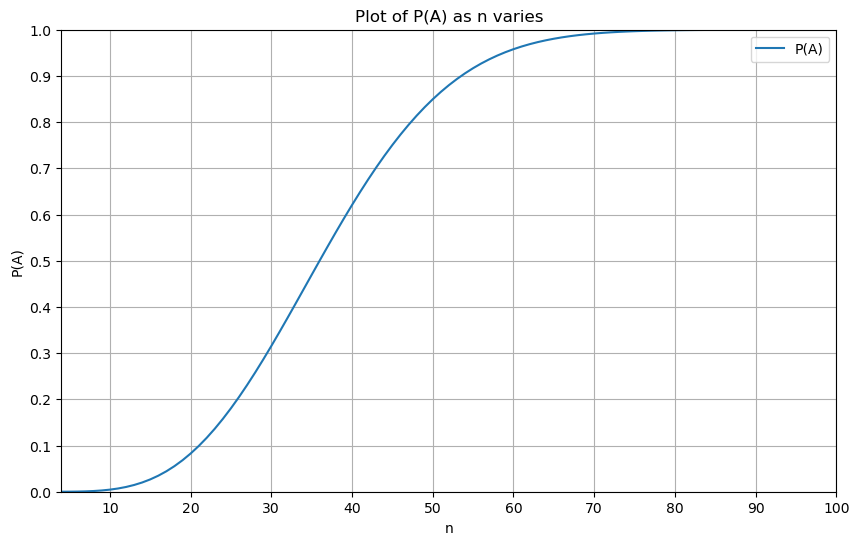

In [10]:
# Generate x values from 2 to 100.
x_values = range(4, 101)

# Compute corresponding f(x) values.
y_values = [pA(x) for x in x_values]

# Create the plot.
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='P(A)')  # 'o' creates a scatter plot
plt.xticks(range(0, 101, 10))  # X-ticks every 10
plt.yticks([i * 0.1 for i in range(0, 11)])  # Y-ticks every 0.1 from -1 to 1
plt.xlim(4, 100)
plt.ylim(0, 1) 
plt.xlabel('n')
plt.ylabel('P(A)')
plt.title('Plot of P(A) as n varies')
plt.legend()
plt.grid(True)
plt.show()